### import relevant libraries

In [7]:
import shutil, os
import numpy as np
import pandas as pd
import math
from math import atan2
import random
import statistics
import csv

%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib import rcParams, cycler
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes,  zoomed_inset_axes
# from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes

import scipy.stats as st
from scipy.stats import bootstrap
from scipy.optimize import curve_fit
from scipy.special import comb


### reading data

In [8]:
data_file = pd.read_excel('rhoda_newdat.xlsx', sheet_name=None)

Hip_Healthy = data_file['Hip_Healthy']
Hip_Patients = data_file['Hip_Patients']
Knee_Healthy = data_file['Knee_Healthy']
Knee_Patients = data_file['Knee_Patients']
Ankle_Healthy = data_file['Ankle_Healthy']
Ankle_Patients= data_file['Ankle_Patients']


### plott original data (of subjects) with average 

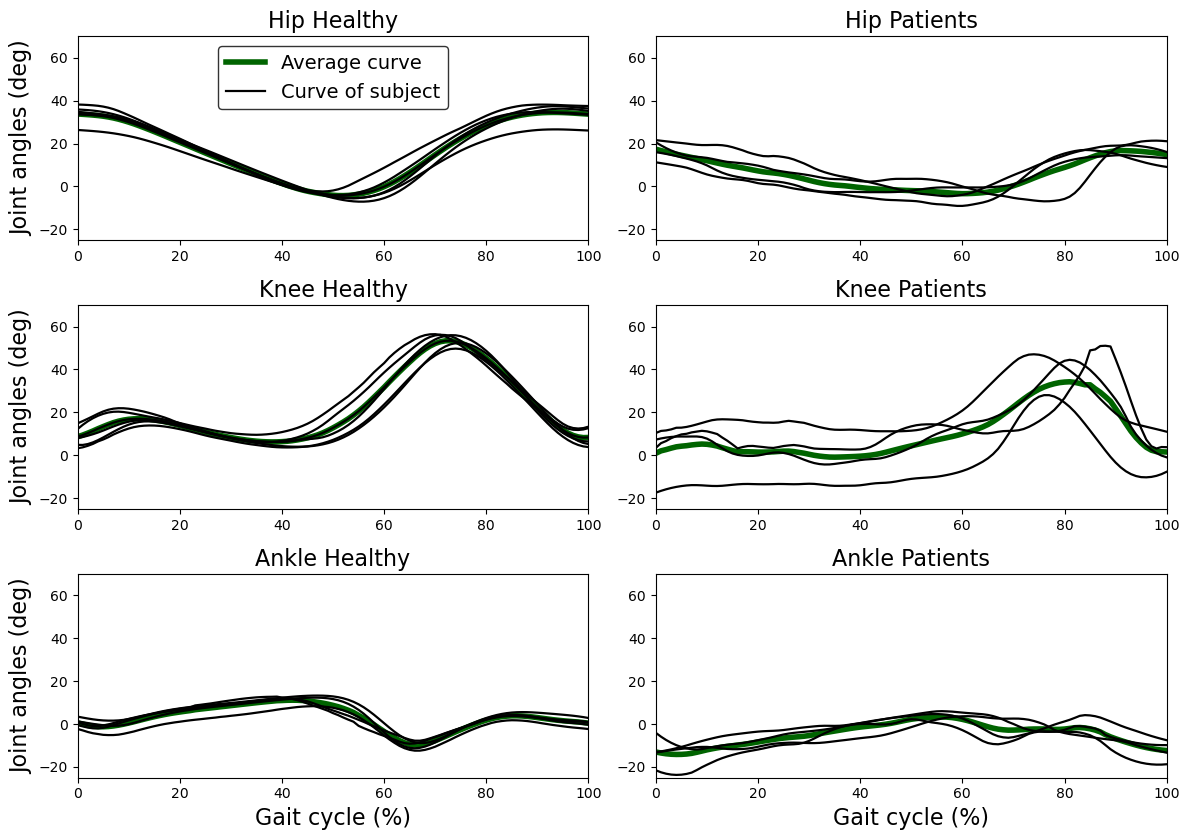

In [10]:
fig = plt.figure(figsize=(12, 8.5))
# fig.suptitle(r'', fontsize=30)
fig.subplots_adjust(hspace=0.3, wspace=0.1) # horizontal and vertical space 

for file in list(data_file.keys()): # names of worksheets
    # average of file (without time)
    av_file=(globals()[file].loc[:,globals()[file].columns != 'Time']).mean(axis=1)
    # range of file (without time)
    range_file=pd.DataFrame()
    ## assumption of normal distirbution of data 
    range_file['low'] = (globals()[file].loc[:,globals()[file].columns != 'Time']).apply(lambda row: st.norm.interval(confidence=0.99,
                                                                      #df=len(globals()[file].loc[:,globals()[file].columns != 'Time'])-1,
                                                                      loc=np.mean(row), 
                                                                      scale=st.sem(row))[0],  axis=1)
    range_file['high'] = (globals()[file].loc[:,globals()[file].columns != 'Time']).apply(lambda row: st.norm.interval(confidence=0.99,
                                                                      #df=len(globals()[file].loc[:,globals()[file].columns != 'Time'])-1,
                                                                      loc=np.mean(row), 
                                                                      scale=st.sem(row))[1],  axis=1)        
    # ## no assumption of distribution of the data
    # range_file['ci'] = (globals()[file].loc[:,globals()[file].columns != 'Time']).apply(lambda row: bootstrap( (np.array(row.to_list()),), np.mean, confidence_level=0.95, method='basic').confidence_interval,  axis=1) # 'percentile', 'BCa'
    # range_file[['low', 'high']] = range_file['ci'].apply(lambda x: pd.Series([x.low, x.high]))
    
    
    ax = fig.add_subplot(3, 2, list(data_file.keys()).index(file) + 1) # fig positioning
   
    ax.plot(globals()[file].loc[:,'Time'], av_file, color='darkgreen', lw=4, alpha = 1, label='Average curve')  # average    
    # ax.plot(globals()[file].loc[:,'Time'], range_file['low'], color='grey', lw= 0) # normal confiddnt interval
    # ax.plot(globals()[file].loc[:,'Time'], range_file['high'], color='grey', lw=0) 
    # ax.fill_between(globals()[file].loc[:,'Time'], range_file['low'], range_file['high'], color='grey', alpha = 0.5,  label='range of curve')    
    
    for subject in list(globals()[file].columns)[1:]: # subjects except 'time' located at first position
        ax.plot(globals()[file].loc[:,'Time'], globals()[file].loc[:,subject], color='black', lw=1.6,label='Curve of subject') # all subjects   
        if all([(list(data_file.keys()).index(file) + 1) == 1, subject == 'HS01']):
            ax.legend(facecolor="white", edgecolor="black", fontsize=14, loc="upper center", ncol=1) 

    ax.set_xlim(0,100) ; ax.set_ylim(-25,70)
    ax.set_title(file.replace('_', ' '), fontsize=16)

    # axis labels
    if (list(data_file.keys()).index(file) + 1) % 2 != 0: # if fig postion is odd
        ax.set_ylabel('Joint angles (deg)', fontsize=16)
    if (list(data_file.keys()).index(file) + 1) == 5 :
        ax.set_xlabel('Gait cycle (%)', fontsize=16)
    if (list(data_file.keys()).index(file) + 1) == 6 :
        ax.set_xlabel('Gait cycle (%)', fontsize=16)
            
plt.tight_layout()  
plt.savefig('Original_Data_Average.pdf', bbox_inches='tight', pad_inches=0, dpi=300)

plt.clf
plt.show()


### Generalised Extension Beinstein function

In [11]:
def bernstein_poly(n, t, i): # n is degree
    # Initialize shape parameters
    lamb = np.zeros(n)

    if n % 2 == 0:  # Even case
        # shape parameters
        if i <= (n // 2 - 2):
            lamb[n - 2 - i] = np.median([-comb(n - 1, i + 1), comb(n - 1, i)])
            lamb[i] = np.median([-comb(n - 1, i + 1), comb(n - 1, i)])
        elif i == (n // 2 - 1):
            lamb[i] = np.median([0, comb(n - 1, n // 2 - 1)])
        elif i in [-1, (n - 1)]:
            lamb[i] = 0


        # GE-Bernstein polynomial
        if i <= (n // 2 - 1):
            GEBC = (comb(n - 1, i) - lamb[i] * t + lamb[i - 1] * (1 - t)) * ((1 - t) ** (n - 1 - i)) * (t ** i)
        elif i == (n // 2):
            GEBC = 2 * lamb[i - 1] * ((1 - t) ** i) * (t ** i)
        elif (n // 2 + 1) <= i <= n:
            GEBC = (comb(n - 1, i - 1) + lamb[i - 1] * t - lamb[i - 2] * (1 - t)) * ((1 - t) ** (n - i)) * (t ** (i - 1))

    else:  # Odd case
        # shape parameter
        if i <= ((n - 1) // 2 - 2):
            lamb[n - 2 - i] = np.median([-comb(n - 1, i + 1), comb(n - 1, i)])
            lamb[i] = np.median([-comb(n - 1, i + 1), comb(n - 1, i)]) ##### 
        elif i in [(n - 1) // 2, (n - 3) // 2]:
            lamb[i] = np.median([-comb(n - 1, (n - 1) // 2), comb(n - 1, (n - 3) // 2)])
        elif i in [-1, (n - 1)]:
            lamb[i] = 0


        # GE-Bernstein polynomial
        if i <= ((n - 1) // 2 - 1):
            GEBC = (comb(n - 1, i) - lamb[i] * t + lamb[i - 1] * (1 - t)) * ((1 - t) ** (n - 1 - i)) * (t ** i)
        elif i in [(n - 1) // 2, (n + 1) // 2]:
            GEBC = (comb(n - 1, (n - 1) // 2) + lamb[i - 1]) * ((1 - t) ** (n - i)) * (t ** i)
        elif ((n + 1) // 2 + 1) <= i <= n:
            GEBC = (comb(n - 1, i - 1) + lamb[i - 1] * t - lamb[i - 2] * (1 - t)) * ((1 - t) ** (n - i)) * (t ** (i - 1))

    return GEBC
 

### Least squares Bézier fit using Moore-Penrose pseudoinverse

In [12]:
import numpy as np
from scipy.special import comb

def get_bezier_parameters(X, Y, degree=3):
    """
    Least squares Bézier fit using Moore-Penrose pseudoinverse.

    Parameters:
    - X: array-like, x-coordinates of data points.
    - Y: array-like, y-coordinates of data points.
    - degree: degree of the Bézier curve (e.g., 2 for quadratic, 3 for cubic).

    Returns:
    - List of fitted control points as [ [x0, y0], [x1, y1], ..., [xn, yn] ]
    """
    
    if degree < 1:
        raise ValueError("Degree must be 1 or greater.")
    if len(X) != len(Y):
        raise ValueError("X and Y must be of the same length.")
    if len(X) < degree + 1:
        raise ValueError(f"Need at least {degree + 1} points to fit a degree {degree} curve.")

    def bernstein_matrix(T):
        """Construct the Bernstein basis matrix."""
        return np.array([[bernstein_poly(degree, t, k) for k in range(degree + 1)] for t in T])

    def least_squares_fit(points, M):
        """Solve for control points using pseudoinverse."""
        return np.linalg.pinv(M) @ points

    T = np.linspace(0, 1, len(X))
    M = bernstein_matrix(T)
    points = np.column_stack((X, Y))

    control_points = least_squares_fit(points, M)
    control_points[0] = [X[0], Y[0]]  # Force start point
    control_points[-1] = [X[-1], Y[-1]]  # Force end point

    return control_points.tolist()


### Generalised Extension Bezier curve

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb


def bezier_curve(points, nTimes=1000):
    """
    Given a set of control points, return the bezier curve defined by the control points.
    """
    
    nPoints = len(points)
    xPoints = np.array([p[0] for p in points])
    yPoints = np.array([p[1] for p in points])

    t = np.linspace(0.0, 1.0, nTimes)
    polynomial_array = np.array([bernstein_poly(nPoints - 1, t, i) for i in range(nPoints)])
    
    xvals = np.dot(xPoints, polynomial_array)
    yvals = np.dot(yPoints, polynomial_array)

    return xvals, yvals

# # Example control points
# control_points = [(1, 1), (2, 3), (4, 5), (7, 4)]

# # Generate Bézier curve
# xvals, yvals = bezier_curve(control_points, nTimes=100)


### CODE - NOT USED

In [7]:

# def bernstein_poly(i, n, t):
    
#     if (n%2 == 0): # n is even case
#         # compute shape parameters as median of the range
#         globals()[f'lamb{-1}'] = 0 ;  globals()[f'lamb{n-1}'] = 0
#         if  (i <= (n/2 - 2)):
#             globals()[f'lamb{n-2-i}'] = np.median([-comb(n-1,i+1),comb(n-1,i)])
#             globals()[f'lamb{i}'] = np.median([-comb(n-1,i+1),comb(n-1,i)])
#         elif (i == (n/2 - 1)) :
#             globals()[f'lamb{i}'] = np.median([0,comb(n-1,n/2-1)])

#         # Bernstein function
#         if (i <= ((n/2) - 1)):
#             GEBC =  (comb(n-1, i) - globals()[f'lamb{i}']  * t  + globals()[f'lamb{i-1}']  * (1-t)) * ((1 - t)**(n - 1 - i)) * t**i
#         elif (i == (n/2)) :
#             GEBC =  2 * globals()[f'lamb{i-1}']  * ((1 - t)**(i)) * t**i
#         elif (((n/2) + 1) <= i <= n):
#             GEBC =  (comb(n-1, i-1) + globals()[f'lamb{i-1}']  * t  - globals()[f'lamb{i-2}']  * (1-t)) * ((1 - t)**(n - i)) * t**(i-1)
    
            
#     else :  # n is odd
#         # shape parameter
#         globals()[f'lamb{-1}'] = 0 ;  globals()[f'lamb{n-1}'] = 0
#         if  (i <= ((n-1)/2 - 2)):
#             globals()[f'lamb{n-2-i}'] = np.median([-comb(n-1,i+1),comb(n-1,i)])
#             globals()[f'lamb{i}'] = np.median([-comb(n-1,i+1),comb(n-1,i)])

#         elif any([(i == (n-1)/2) , (i ==  (n-3)/2)]) :
#             globals()[f'lamb{i}'] = np.median([comb(n-1,(n-1)/2), comb(n-1,(n-3)/2)])

#         # Bernstein function
#         if (i <= (((n-1)/2) - 1)):
#             GEBC =  (comb(n-1, i) - globals()[f'lamb{i}']  * t  + globals()[f'lamb{i-1}']  * (1-t)) * ((1 - t)**(n - 1 - i)) * t**i
#         elif any([(i == (n-1)/2) , (i ==  (n+1)/2)]) :   
#             GEBC =  (comb(n-1, (n-1)/2)  + globals()[f'lamb{i-1}']) * ((1 - t)**(n-i)) * t**i
#         elif (((n+1)/2 + 1) <= i <= n):
#             GEBC =  (comb(n-1, i-1) + globals()[f'lamb{i-1}']  * t  - globals()[f'lamb{i-2}']  * (1-t)) * ((1 - t)**(n - i)) * t**(i-1)

#     return GEBC

                
###-----------------------------------------------------------------------------------------------------------###            
# def bernstein_poly(n, t, k): # n is degree
#     # Initialize shape parameters
#     lamb = np.zeros(n)

#     if n % 2 == 0:  # Even case
#         # shape parameters
#         if i <= (n // 2 - 2):
#             lamb[n - 2 - i] = np.median([-comb(n - 1, i + 1), comb(n - 1, i)])
#             lamb[i] = np.median([-comb(n - 1, i + 1), comb(n - 1, i)])
#         elif i == (n // 2 - 1):
#             lamb[i] = np.median([0, comb(n - 1, n // 2 - 1)])
#         elif i in [-1, (n - 1)]:
#             lamb[i] = 0


#         # GE-Bernstein polynomial
#         if i <= (n // 2 - 1):
#             GEBC = (comb(n - 1, i) - lamb[i] * t + lamb[i - 1] * (1 - t)) * ((1 - t) ** (n - 1 - i)) * (t ** i)
#         elif i == (n // 2):
#             GEBC = 2 * lamb[i - 1] * ((1 - t) ** i) * (t ** i)
#         elif (n // 2 + 1) <= i <= n:
#             GEBC = (comb(n - 1, i - 1) + lamb[i - 1] * t - lamb[i - 2] * (1 - t)) * ((1 - t) ** (n - i)) * (t ** (i - 1))

#     else:  # Odd case
#         # shape parameter
#         if i <= ((n - 1) // 2 - 2):
#             lamb[n - 2 - i] = np.median([-comb(n - 1, i + 1), comb(n - 1, i)])
#             lamb[i] = np.median([-comb(n - 1, i + 1), comb(n - 1, i)])
#         elif i in [(n - 1) // 2, (n - 3) // 2]:
#             lamb[i] = np.median([-comb(n - 1, (n - 1) // 2), comb(n - 1, (n - 3) // 2)])
#         elif i in [-1, (n - 1)]:
#             lamb[i] = 0


#         # GE-Bernstein polynomial
#         if i <= ((n - 1) // 2 - 1):
#             GEBC = (comb(n - 1, i) - lamb[i] * t + lamb[i - 1] * (1 - t)) * ((1 - t) ** (n - 1 - i)) * (t ** i)
#         elif i in [(n - 1) // 2, (n + 1) // 2]:
#             GEBC = (comb(n - 1, (n - 1) // 2) + lamb[i - 1]) * ((1 - t) ** (n - i)) * (t ** i)
#         elif ((n + 1) // 2 + 1) <= i <= n:
#             GEBC = (comb(n - 1, i - 1) + lamb[i - 1] * t - lamb[i - 2] * (1 - t)) * ((1 - t) ** (n - i)) * (t ** (i - 1))

#     return GEBC
 
    
# ###----------------------------------------------------------------------------------------###    
# def get_bezier_parameters(X, Y, degree=4):
#     """ Least square qbezier fit using penrose pseudoinverse.

#     Parameters:

#     X: array of x data.
#     Y: array of y data. 
#     Y[0] is the y point for X[0].
#     degree: degree of the Bézier curve. 2 for quadratic, 3 for cubic.

#     Based on https://stackoverflow.com/questions/12643079/b%C3%A9zier-curve-fitting-with-scipy
#     and probably on the 1998 thesis by Tim Andrew Pastva, "Bézier Curve Fitting".
#     """
    
#     if degree < 1:
#         raise ValueError('degree must be 1 or greater.')

#     if len(X) != len(Y):
#         raise ValueError('X and Y must be of the same length.')

#     if len(X) < degree + 1:
#         raise ValueError(f'There must be at least {degree + 1} points to '
#                          f'determine the parameters of a degree {degree} curve. '
#                          f'Got only {len(X)} points.')

#     def bmatrix(T):
#         """ Bernstein matrix for Bézier curves. """
#         return np.matrix([[bernstein_poly(i, degree, t) for i in range(degree + 1)] for t in T])

#     def least_square_fit(points, M):
#         M_ = np.linalg.pinv(M)
#         return M_ * points

#     T = np.linspace(0, 1, len(X))
#     M = bmatrix(T)
#     points = np.array(list(zip(X, Y)))
    
#     final = least_square_fit(points, M).tolist()
#     final[0] = [X[0], Y[0]]
#     final[len(final)-1] = [X[len(X)-1], Y[len(Y)-1]]
#     return final

# ###-----------------------------------------------------------------------------------------------------------###            


# def bezier_curve(points, nTimes=1000):
#     """
#        Given a set of control points, return the
#        bezier curve defined by the control points.

#        points should be a list of lists, or list of tuples
#        such as [ [1,1], 
#                  [2,3], 
#                  [4,5], ..[Xn, Yn] ]
#         nTimes is the number of time steps, defaults to 1000

#         See http://processingjs.nihongoresources.com/bezierinfo/
#     """

#     nPoints = len(points)
#     xPoints = np.array([p[0] for p in points])
#     yPoints = np.array([p[1] for p in points])

#     t = np.linspace(0.0, 1.0, nTimes)

#     polynomial_array = np.array([ bernstein_poly(i, nPoints-1, t) for i in range(0, nPoints)   ])

#     xvals = np.dot(xPoints, polynomial_array)
#     yvals = np.dot(yPoints, polynomial_array)

#     return xvals, yvals


### Beizer curves with optimal control points

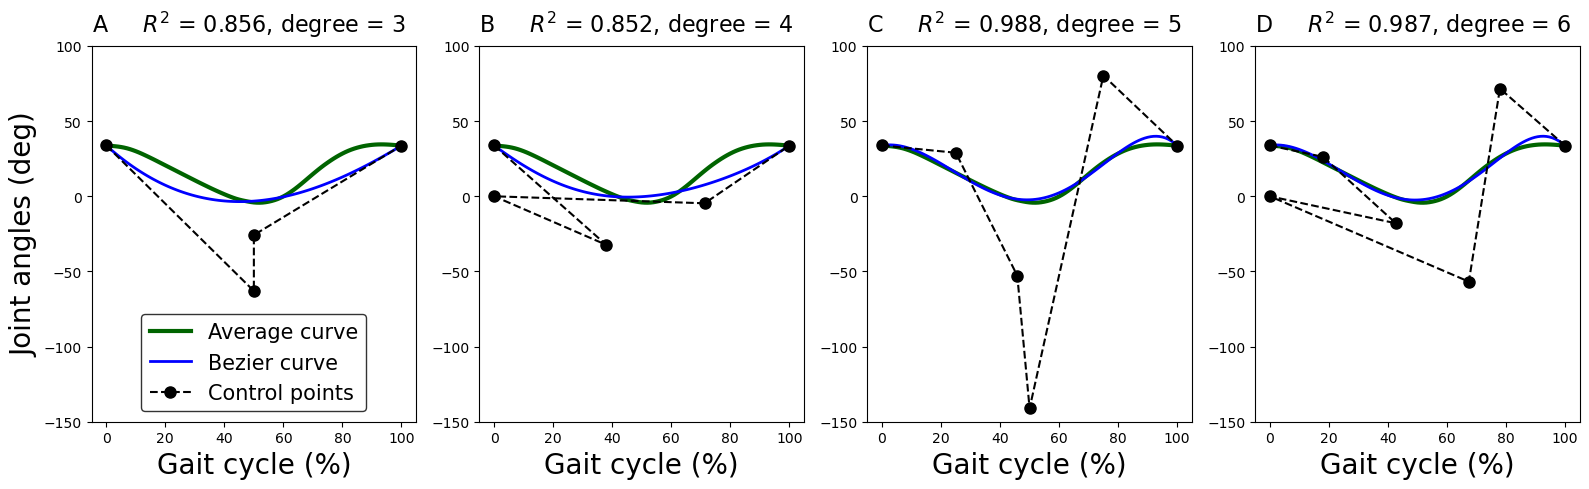

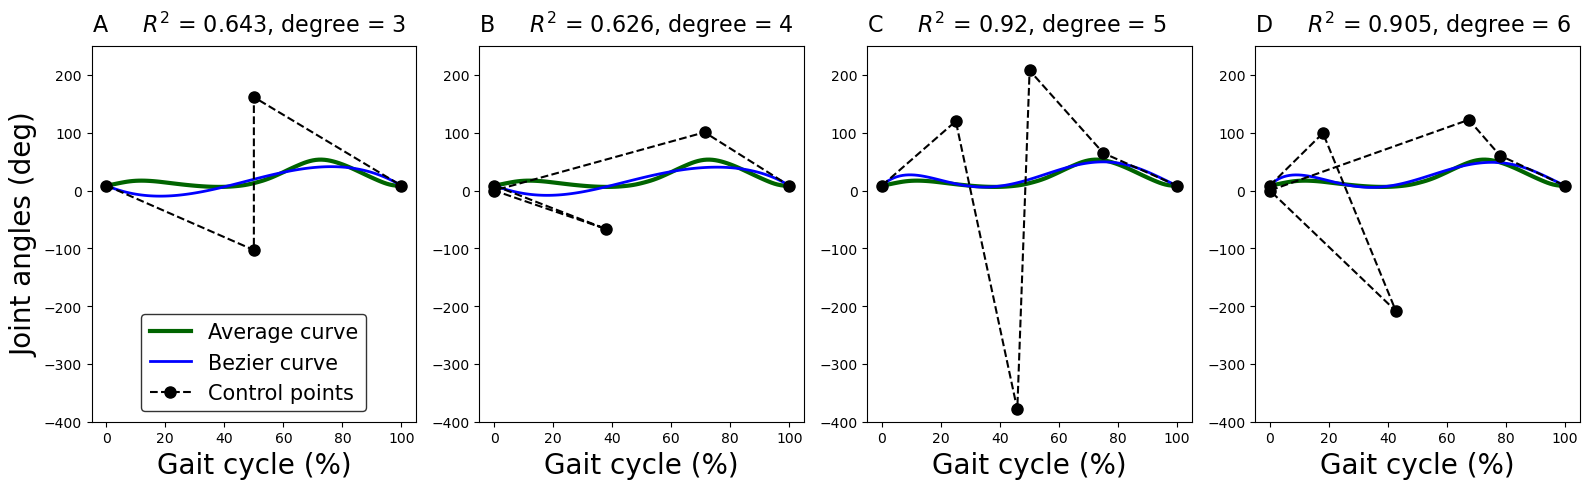

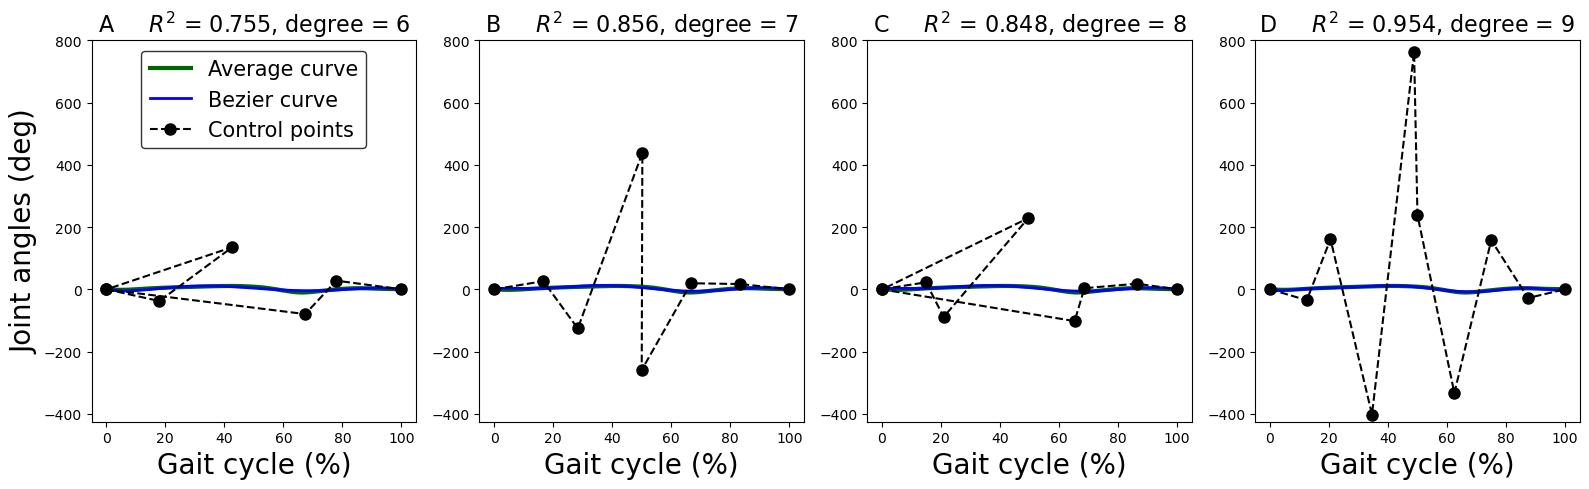

In [14]:
# fig = plt.figure(figsize=(13, 8))
# fig.subplots_adjust(hspace=0.3, wspace=0.1) # horizontal and vertical space 

list_healthy = ['Hip_Healthy', 'Knee_Healthy', 'Ankle_Healthy']
for i in range(3):
    for file in [list_healthy[i]]: 
        av_file=(globals()[file].loc[:,globals()[file].columns != 'Time']).mean(axis=1)  # average of file (without time)
        
        fig = plt.figure(figsize=(16, 5))
        # fig.suptitle(file.replace('_',' '), fontsize=20)
        fig.subplots_adjust(hspace=0.3, wspace=0.1) # horizontal and vertical space

        num_deg = [3,4,5,6]
        for deg in num_deg :
            ax = fig.add_subplot(1, 4, num_deg.index(deg) + 1) # fig positioning
            ax.plot(globals()[file].loc[:,'Time'], av_file, color='darkgreen', lw=3, alpha = 1, label='Average curve')  # average 
            
            if i in [0,1]:
                # Get the Bezier parameters based on a degree.
                data = get_bezier_parameters(np.array(globals()[file].loc[:,'Time']), np.array(av_file), degree=deg)
                x_val = [x[0] for x in data]
                y_val = [x[1] for x in data]
            else:
                deg1=deg+3
                data = get_bezier_parameters(np.array(globals()[file].loc[:,'Time']), np.array(av_file), degree=deg1)
                x_val = [x[0] for x in data]
                y_val = [x[1] for x in data]
                

            # Plot the resulting Bezier curve
            xvals, yvals = bezier_curve(data, nTimes=101)
            ax.plot(xvals, yvals, 'blue', lw=2,label='Bezier curve')

            # Plot the resulting control points
            ax.plot(x_val,y_val,'k--o', label='Control points',markersize=8)
            
            if i ==0:
                ax.set_ylim(-150,100) ; ax.set_xlim(-5,105)
            elif i==1:
                ax.set_ylim(-400,250) ; ax.set_xlim(-5,105)
            else:
                ax.set_ylim(-425,800) ; ax.set_xlim(-5,105)
                

            if ((num_deg.index(deg) + 1) == 1):
                if i == 0:
                    ax.legend(facecolor="white", edgecolor="black", fontsize=15, loc="lower center",ncol=1)
                elif i ==1:
                    ax.legend(facecolor="white", edgecolor="black", fontsize=15, loc="lower center",ncol=1)
                else:
                    ax.legend(facecolor="white", edgecolor="black", fontsize=15, loc="upper center",ncol=1)
               

            # R - squared
            import string
            corr_matrix = np.corrcoef(av_file, yvals)
            corr = corr_matrix[0,1]
            R_sq = corr**2
            if i in [0,1]:
                ax.set_title(string.ascii_uppercase[num_deg.index(deg)] + '     ' + '$R^2$ = ' + str(round(R_sq,3)) + ',' + ' ' + 'degree = ' + str(deg) , loc="left",  pad=10, fontsize=16)
            else:
                ax.set_title(string.ascii_uppercase[num_deg.index(deg)] + '     ' + '$R^2$ = ' + str(round(R_sq,3)) + ',' + ' ' + 'degree = ' + str(deg1) , fontsize=16)
 
            
            # axis labels
            if ((num_deg.index(deg) + 1) == 1): # if fig postion is odd
                ax.set_ylabel('Joint angles (deg)', fontsize=20)
            ax.set_xlabel('Gait cycle (%)', fontsize=20)
            # if ((num_deg.index(deg) + 1) % 2 != 0): # if fig postion is odd
            #     ax.set_ylabel('Joint angles (deg)', fontsize=20)
            # if (num_deg.index(deg) + 1) == 3 :
            #     ax.set_xlabel('Gait cycle (%)', fontsize=20)
            # if (num_deg.index(deg) + 1) == 4 :
            #     ax.set_xlabel('Gait cycle (%)', fontsize=20)


    plt.tight_layout()  
    plt.savefig("Optimal_%s.pdf" % file, bbox_inches='tight', pad_inches=0.1, dpi=300)   

plt.clf
plt.show()


### compute the optimal control points values

In [15]:
## returns the optimal control points values
## arranaged as HIP-HEALTHY, HIP-PATIENTS, KNEE-HEALTHY, KNEE-PATIENTS, ANKLE-HEALTHY, ANKLE-PATIENTS

control_points =[] ; x_vals=[] ; y_vals=[]
control_names =['Hip_Healthy','Hip_Patients','Knee_Healthy','Knee_Patients','Ankle_Healthy','Ankle_Patients']
for i in range(6):
    for file in list(data_file.keys())[i:(i+1)]: # names of worksheets
        av_file=(globals()[file].loc[:,globals()[file].columns != 'Time']).mean(axis=1)    # average of file (without time)

        if i in [0,1,2,3]:
            opt_deg = 5
            # Get the Bezier parameters based on a degree.
            data = get_bezier_parameters(np.array(globals()[file].loc[:,'Time']), np.array(av_file), degree=opt_deg)
            data = [[round(num, 3) for num in sublist] for sublist in data]
            x_val = [x[0] for x in data]
            y_val = [x[1] for x in data]
        elif i in [4,5]:
            opt_deg = 7
            # Get the Bezier parameters based on a degree.
            data = get_bezier_parameters(np.array(globals()[file].loc[:,'Time']), np.array(av_file), degree=opt_deg)
            data = [[round(num, 3) for num in sublist] for sublist in data]
            x_val = [x[0] for x in data]
            y_val = [x[1] for x in data] 
            
           
            
        control_points.append(data)
        x_vals.append(x_val)
        y_vals.append(y_val)
control = dict(zip(control_names, control_points))
control


{'Hip_Healthy': [[0.0, 33.797],
  [25.0, 28.97],
  [45.833, -52.851],
  [50.0, -141.122],
  [75.0, 80.338],
  [100.0, 33.72]],
 'Hip_Patients': [[0.0, 17.359],
  [25.0, -14.45],
  [45.833, 52.202],
  [50.0, -114.267],
  [75.0, 38.343],
  [100.0, 14.878]],
 'Knee_Healthy': [[0.0, 8.65],
  [25.0, 119.95],
  [45.833, -378.752],
  [50.0, 207.705],
  [75.0, 64.635],
  [100.0, 8.305]],
 'Knee_Patients': [[0.0, 0.945],
  [25.0, 19.394],
  [45.833, -46.643],
  [50.0, -126.389],
  [75.0, 123.563],
  [100.0, 1.534]],
 'Ankle_Healthy': [[0.0, 0.535],
  [16.667, 26.512],
  [28.333, -125.288],
  [50.208, 438.276],
  [50.0, -258.815],
  [66.667, 19.915],
  [83.333, 17.355],
  [100.0, 0.422]],
 'Ankle_Patients': [[0.0, -12.997],
  [16.667, -3.653],
  [28.333, -14.354],
  [50.208, 25.025],
  [50.0, 51.081],
  [66.667, -28.65],
  [83.333, 10.734],
  [100.0, -12.331]]}

### Determine optimal shape parameters (saved as CSV) for fitting subject Bezier curves (plots)

In [18]:

# Define the custom Bernstein polynomial function with shape parameters
def bernstein_poly1(n, t, i, lamb):
    if n % 2 == 0:  # Even case
        if i <= (n // 2 - 1):
            GEBC = (comb(n - 1, i) - lamb[i] * t + lamb[i - 1] * (1 - t)) * ((1 - t) ** (n - 1 - i)) * (t ** i)
        elif i == (n // 2):
            GEBC = 2 * lamb[i - 1] * ((1 - t) ** i) * (t ** i)
        elif (n // 2 + 1) <= i <= n:
            GEBC = (comb(n - 1, i - 1) + lamb[i - 1] * t - lamb[i - 2] * (1 - t)) * ((1 - t) ** (n - i)) * (t ** (i - 1))
        else:
            GEBC = np.zeros_like(t)
    
    else:  # Odd case
        if i <= ((n - 1) // 2 - 1):
            GEBC = (comb(n - 1, i) - lamb[i] * t + lamb[i - 1] * (1 - t)) * ((1 - t) ** (n - 1 - i)) * (t ** i)
        elif i in [(n - 1) // 2, (n + 1) // 2]:
            GEBC = (comb(n - 1, (n - 1) // 2) + lamb[i - 1]) * ((1 - t) ** (n - i)) * (t ** i)
        elif ((n + 1) // 2 + 1) <= i <= n:
            GEBC = (comb(n - 1, i - 1) + lamb[i - 1] * t - lamb[i - 2] * (1 - t)) * ((1 - t) ** (n - i)) * (t ** (i - 1))
        else:
            GEBC = np.zeros_like(t)
    return GEBC


# Wrapper function for curve_fit that multiplies each basis function by control points
def bernstein_fit_func(t, *lamb):
    n = len(lamb)
    # ctrl_pnts = np.array(control_points[i])
    result = np.zeros_like(t)
    for i in range(n + 1):
        basis = bernstein_poly1(n, t, i, lamb)
        result += basis * ctrl_pnts[i][1]  # Multiply by y-coordinate of control point
    return result 

##------------------------------------------------------------------------------###

for i in range(6):
    for file in list(data_file.keys())[i:(i+1)]: # names of worksheets
        
        
        ctrl_pnts = np.array(control_points[i]) # associated control points
        
        # LAMB0 = [] ; LAMB1 = [] ; LAMB2 = [] 
        # create empty list for shp parameter
        num_shp = len(ctrl_pnts) - 2 # nr. of shp
        for j in range(num_shp):
            globals()[f'LAMB{j}'] = []

        fig = plt.figure(figsize=(14, 8))
        fig.suptitle(file.replace('_',' '), fontsize=20)
        fig.subplots_adjust(hspace=0.3, wspace=0.1) # horizontal and vertical space
        idx = 1 # index for plotting
        
        globals()[f'Fitted_'+ file] = pd.DataFrame() # create empty dataframe

        for subject in list(globals()[file].columns)[1:]: # subjects except 'time' located at first position
            xdat =  np.array(globals()[file].loc[:,'Time'])
            ydat =  np.array(globals()[file].loc[:,subject])

            t = np.linspace(0, 1, 101)
            initial_guess = [0] * num_shp
            # Fit the data using curve_fit
            pars, cov = curve_fit(bernstein_fit_func, t, ydat, p0=initial_guess)
            # Evaluate the fitted curve
            fitted_curve = bernstein_fit_func(t, *pars)
            
            # append columns with headers
            (globals()[f'Fitted_'+ file])[subject] = fitted_curve

            # LAMB0.append(pars[0]) ; LAMB1.append(pars[1]) ; LAMB2.append(pars[2])
            # Append nth value to nth list
            for j, value in enumerate(pars):
                globals()[f'LAMB{j}'].append(value)
                
            ax = fig.add_subplot(2, 3, idx) # fig positioning
            ax.set_title(subject)
            ax.plot(xdat, ydat, color='black', lw=3, alpha = 1, label='Subject curve')  # average 
            ax.plot(xdat, fitted_curve, color='black', linestyle='--', lw=2, alpha = 1, label='Fitted Bezier curve')  # average 
            
            ax.set_xlim(0,100) ; ax.set_ylim(-25,70)
            if (idx == 1):
                ax.legend(facecolor="white", edgecolor="black", fontsize=15, loc="upper center",ncol=1)
            if idx in [1,4]: 
                ax.set_ylabel('Joint angles (deg)', fontsize=20)
            ax.set_xlabel('Gait cycle (%)', fontsize=20)
            idx = idx + 1
        
        
         ## assumption of normal distirbution of data 
        (globals()[f'Fitted_'+ file])['low'] = (globals()[f'Fitted_'+ file]).apply(lambda row: st.norm.interval(confidence=0.99,
                                                                                  loc=np.mean(row), 
                                                                                  scale=st.sem(row))[0],  axis=1)
        (globals()[f'Fitted_'+ file])['high'] = (globals()[f'Fitted_'+ file]).apply(lambda row: st.norm.interval(confidence=0.99,
                                                                                loc=np.mean(row), 
                                                                                  scale=st.sem(row))[1],  axis=1)        
        
#         # ## no assumption of distribution of the data
#         range_file=pd.DataFrame()
#         range_file['ci'] = (globals()[f'Fitted_'+ file]).apply(lambda row: bootstrap( (np.array(row.to_list()),), np.mean, confidence_level=0.95, method='basic').confidence_interval,  axis=1) # 'percentile', 'BCa'
#         (globals()[f'Fitted_'+ file])[['low', 'high']]= range_file['ci'].apply(lambda x: pd.Series([x.low, x.high]))
        
        csvfile = 'Shape_Parameter_' + file + '.csv'    # a csv-file output 
        # header = ['SUBJECT','LAMB0' ,'LAMB1','LAMB2']
        header = ['SUBJECT'] + ['LAMB' + str(i) for i in range(num_shp)]
        # main_data = [list(globals()[file].columns)[1:], LAMB0, LAMB1, LAMB2]
        main_data = [list(globals()[file].columns)[1:]] + [globals()[f'LAMB{i}'] for i in range(num_shp)]
        with open(csvfile, "w") as output:
            writer = csv.writer(output) 
            writer.writerow(header)
            writer.writerows(zip(*main_data))

        plt.tight_layout()  
        plt.savefig("Fitted_Bezier_%s.pdf" % file, bbox_inches='tight', pad_inches=0.1, dpi=300)   
     

### compute the range of Bezier curves for healthy

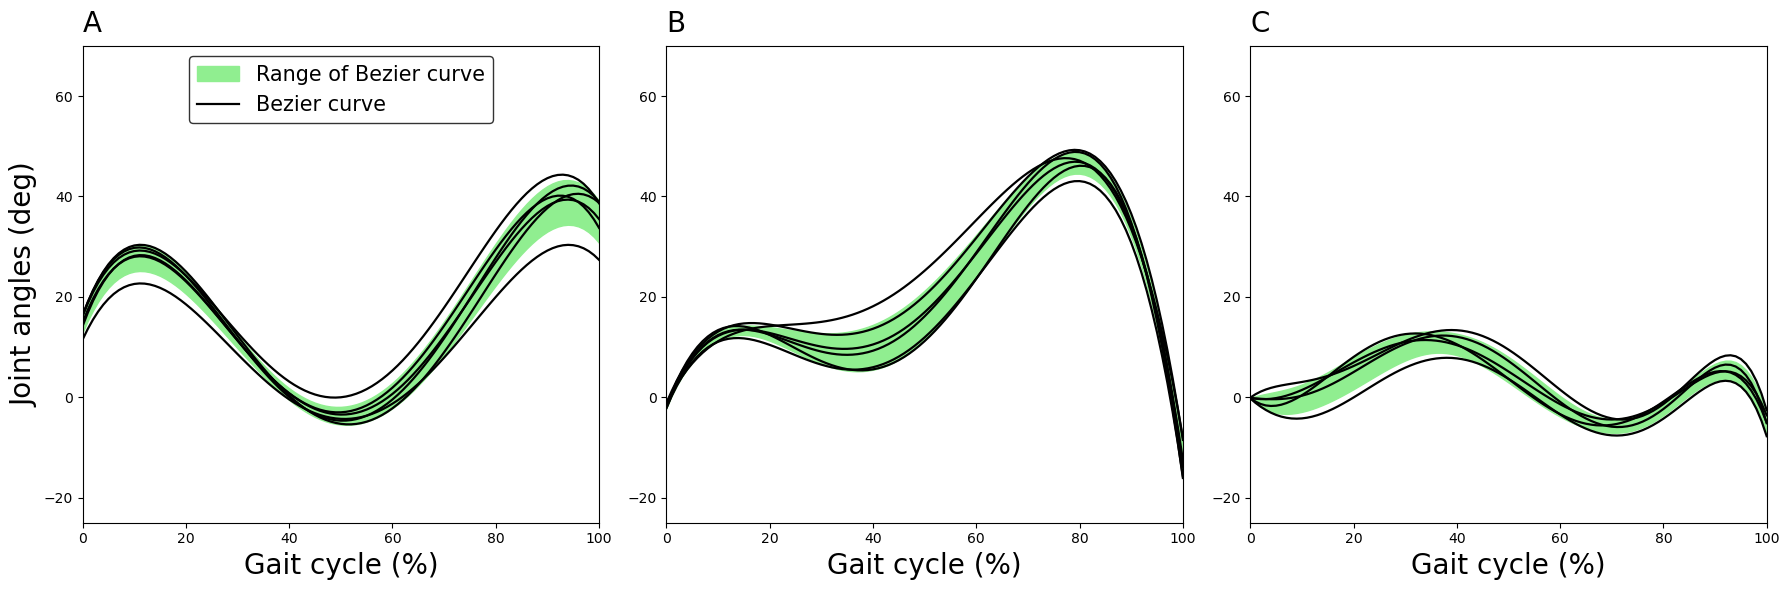

In [20]:
# the curves created from previous step
# Fitted_curves = ['Fitted_Hip_Healthy','Fitted_Hip_Patients', 'Fitted_Knee_Healthy',
#                  'Fitted_Knee_Patients', 'Fitted_Ankle_Healthy', 'Fitted_Ankle_Patients']
Fitted_curves = ['Fitted_Hip_Healthy', 'Fitted_Knee_Healthy', 'Fitted_Ankle_Healthy']

fig = plt.figure(figsize=(18, 6))
# # fig.suptitle(file + ':'  + ' ' + r'subject curve versus fitted Bezier curve' , fontsize=20)
fig.subplots_adjust(hspace=0.3, wspace=0.1) # horizontal and vertical space

for file in Fitted_curves: 
    ax = fig.add_subplot(1, 3, Fitted_curves.index(file) + 1) # fig positioning
    ax.fill_between(np.arange(0,101), globals()[file].loc[:,'low'], globals()[file].loc[:,'high'], color='lightgreen', alpha = 1,  label='Range of Bezier curve')    
    
    for subject in list(globals()[file].columns)[:-2]: # exclude last two columns (i.e., low, high)
        ax.plot(np.arange(0,101), globals()[file].loc[:,subject],color='black', lw=1.6, alpha = 1, label='Bezier curve')  # average 
        if Fitted_curves.index(file) == 0 and subject == 'HS01' :
            ax.legend(facecolor="white", edgecolor="black", fontsize=15, loc="upper center", ncol=1)
#     ax.plot(np.arange(0,101), globals()[file].loc[:, ~globals()[file].columns.isin(['low', 'high'])],color='black', lw=1.6, alpha = 1, label='Bezier curve')  # average    
#     ax.fill_between(np.arange(0,101), globals()[file].loc[:,'low'], globals()[file].loc[:,'high'], color='lightgreen', alpha = 1,  label='Range of Bezier curve')    
    
    
    if (Fitted_curves.index(file) + 1) == 1:
        ax.set_ylabel('Joint angles (deg)', fontsize=20)
    ax.set_xlabel('Gait cycle (%)', fontsize=20)
    # ax.set_title(file.replace('_',' ')[7:], fontsize=20)
    import string
    ax.set_title(f"{string.ascii_uppercase[Fitted_curves.index(file)]}",  loc="left",  pad=10, fontsize=20)
    ax.set_xlim(0,100) ; ax.set_ylim(-25,70)

plt.tight_layout()  
plt.savefig("Fitted_Range_Healthy.pdf", bbox_inches='tight', pad_inches=0.1, dpi=300)   

plt.clf
plt.show()


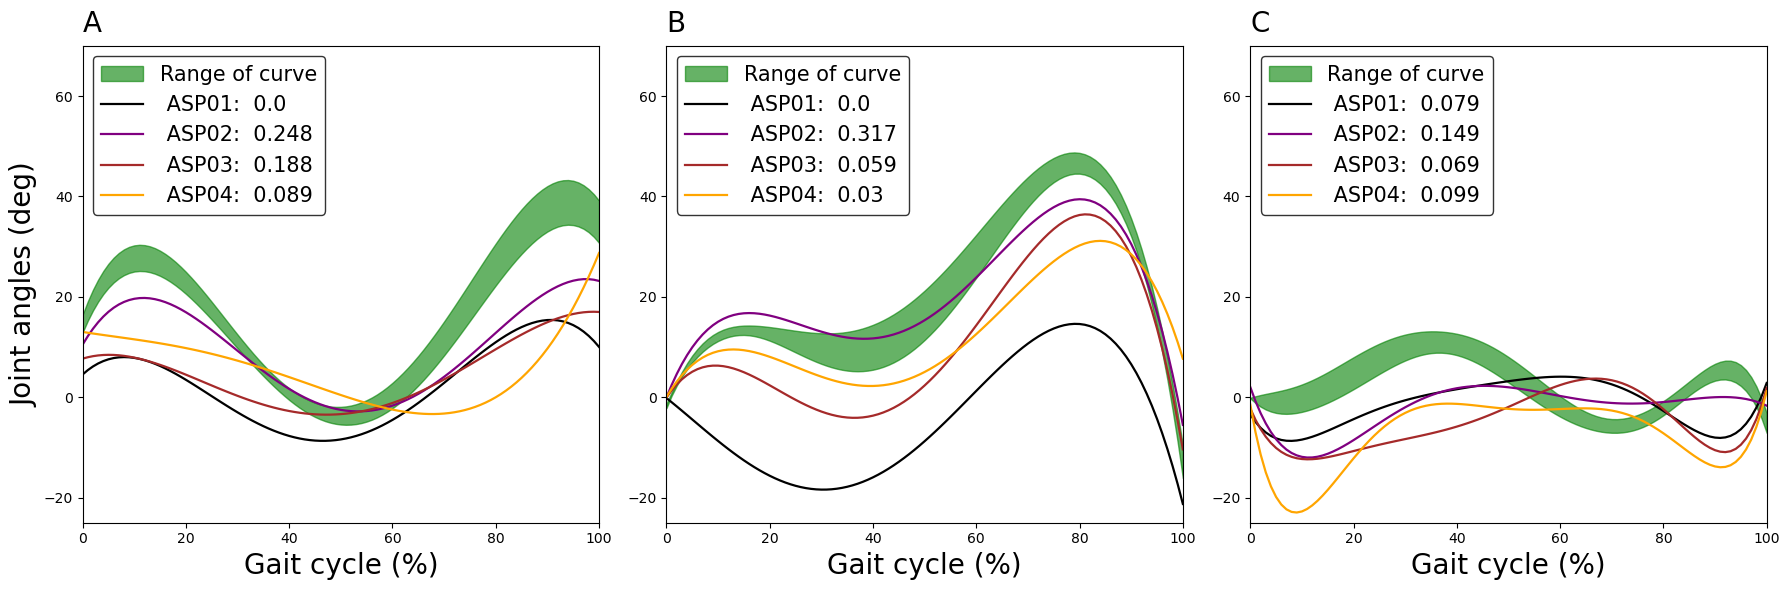

In [21]:
# Fitted_curves = ['Fitted_Hip_Healthy','Fitted_Hip_Patients', 'Fitted_Knee_Healthy',
#                  'Fitted_Knee_Patients', 'Fitted_Ankle_Healthy', 'Fitted_Ankle_Patients']

# drop low/high columns from patients
Hip_Healthy_Patients = globals()['Fitted_Hip_Patients'].drop(columns=['low', 'high'])
# concatinate low/high of healthy to patients
Hip_Healthy_Patients = pd.concat([Hip_Healthy_Patients, globals()['Fitted_Hip_Healthy'][['low','high']] ], axis=1) 

Knee_Healthy_Patients = globals()['Fitted_Knee_Patients'].drop(columns=['low', 'high'])
Knee_Healthy_Patients = pd.concat([Knee_Healthy_Patients, globals()['Fitted_Knee_Healthy'][['low','high']] ], axis=1)

Ankle_Healthy_Patients = globals()['Fitted_Ankle_Patients'].drop(columns=['low', 'high'])
Ankle_Healthy_Patients = pd.concat([Ankle_Healthy_Patients, globals()['Fitted_Ankle_Healthy'][['low','high']] ], axis=1)

scores = pd.DataFrame() # create empty dataframe
Fitted_curves = ['Hip_Healthy_Patients','Knee_Healthy_Patients', 'Ankle_Healthy_Patients']
fig = plt.figure(figsize=(18, 6))
# # fig.suptitle(file + ':'  + ' ' + r'subject curve versus fitted Bezier curve' , fontsize=20)
fig.subplots_adjust(hspace=0.3, wspace=0.1) # horizontal and vertical space

for file in Fitted_curves: 
    ax = fig.add_subplot(1, 3, Fitted_curves.index(file) + 1) # fig positioning
    ax.fill_between(np.arange(0,101), globals()[file].loc[:,'low'], globals()[file].loc[:,'high'], color='green', alpha = 0.6,  label='Range of curve')    
    j=0
    col=['black','purple','brown','orange']
    for subject in list(globals()[file].columns)[:-2]: # exclude last two columns (i.e., low, high)
        
        ## This approach scores the B-curves of patients, whether they fall inside the healthy range
        ## (in which case it's scored 1) or outside the range (in which case it is scored 0), and then 
        ## summed up and divided by number of time points
        scores[subject]= globals()[file].apply(lambda row:  1 if row['low'] <= row[subject] <= row['high'] else 0, axis=1)
        metric = scores.apply(lambda col: round(col.sum()/len(col),3))
        metric = metric.to_dict()
        
        ax.plot(np.arange(0,101), globals()[file].loc[:,subject],color=col[j], lw=1.6, alpha = 1, label=subject + ':' + '  ' +str(metric[subject]))  # average 
        j = j + 1
        # if Fitted_curves.index(file) == 0 :
        ax.legend(facecolor="white", edgecolor="black", fontsize=15, loc="upper left", ncol=1)
    # ax.plot(np.arange(0,101), globals()[file].loc[:, ~globals()[file].columns.isin(['low', 'high'])],color='black', lw=1.6, alpha = 1, label='Fitted Bezier curve')  # average    
    # ax.fill_between(np.arange(0,101), globals()[file].loc[:,'low'], globals()[file].loc[:,'high'], color='green', alpha = 0.6,  label='Range of curve')    
  
    if (Fitted_curves.index(file) + 1) == 1:
        ax.set_ylabel('Joint angles (deg)', fontsize=20)
    ax.set_xlabel('Gait cycle (%)', fontsize=20)
    # ax.set_title(file.replace('_',' ')[:-9], fontsize=20)
    import string
    ax.set_title(f"{string.ascii_uppercase[Fitted_curves.index(file)]}",  loc="left",  pad=10, fontsize=20)
    ax.set_xlim(0,100) ; ax.set_ylim(-25,70)
    
plt.tight_layout()  
plt.savefig("Fitted_Healthy_Patients.pdf", bbox_inches='tight', pad_inches=0.1, dpi=300) 

plt.clf
plt.show()
     

### determine patients shp-parmater is within the healthy shp-parameter

In [22]:
csvfiles=[
         'Shape_Parameter_Hip_Healthy.csv', 'Shape_Parameter_Hip_Patients.csv',
         'Shape_Parameter_Knee_Healthy.csv', 'Shape_Parameter_Knee_Patients.csv',
         'Shape_Parameter_Ankle_Healthy.csv', 'Shape_Parameter_Ankle_Patients.csv'
         ]

for csvfile in csvfiles:
    filename = csvfile[:-4] # remove last 4 characters from name
    globals()[f"%s"%(filename)]=pd.read_csv(csvfile, header=0)

Healthy_files=[Shape_Parameter_Hip_Healthy, Shape_Parameter_Knee_Healthy, Shape_Parameter_Ankle_Healthy]   
Patients_files=[Shape_Parameter_Hip_Patients, Shape_Parameter_Knee_Patients, Shape_Parameter_Ankle_Patients]  
     
for file1, file2 in zip(Patients_files,Healthy_files):
    shp_metric = file1.copy() # create empty dataframe
    # Healthy_metrics  = globals()[file2] 
    for subject in file1.columns[1:]:
        max_val = file2[subject].max()
        min_val = file2[subject].min()
        range_val= max_val - min_val
        shp_metric[subject] = file1[subject].apply(lambda val: 1 if min_val <= val <= max_val else 0 ) #(val - min_val)/ range_val)
    print(shp_metric)   


  SUBJECT  LAMB0  LAMB1  LAMB2  LAMB3
0   ASP01      0      0      0      0
1   ASP02      0      0      1      0
2   ASP03      0      0      0      1
3   ASP04      0      0      0      0
  SUBJECT  LAMB0  LAMB1  LAMB2  LAMB3
0   ASP01      0      0      0      1
1   ASP02      0      0      0      0
2   ASP03      0      0      0      0
3   ASP04      0      0      0      0
  SUBJECT  LAMB0  LAMB1  LAMB2  LAMB3  LAMB4  LAMB5
0   ASP01      0      0      0      0      0      0
1   ASP02      0      0      0      0      0      1
2   ASP03      0      0      0      0      0      0
3   ASP04      0      0      0      0      0      0
